In [1]:
using Pkg
Pkg.activate(@__DIR__)
Pkg.develop(url = "https://github.com/IncartStudents/IBoxAccess.jl")
Pkg.develop(url = "https://github.com/IncartStudents/Descriptors.jl")
Pkg.develop(url = "https://github.com/a-mikhaylov/FileUnv_jll.jl.git")
Pkg.develop(url = "https://github.com/sairus7/wfdb_wrapper_jll.jl.git")
Pkg.develop(url = "https://github.com/IncartStudents/FileUtils.jl")
Pkg.develop(url = "https://github.com/IncartStudents/TimeSamplings.jl")
Pkg.develop(path=joinpath(@__DIR__, ".."))   # путь к корню пакета (без "src")
using ArrhythmRelations
Pkg.add("Plots")
using Plots

  Activating project at `c:\Users\rika\Documents\etu\incart\ArrhythmRelations.jl\test`
     Cloning git-repo `https://github.com/IncartStudents/IBoxAccess.jl`
Path `C:\Users\rika\.julia\dev\IBoxAccess` exists and looks like the correct repo. Using existing path.
   Resolving package versions...
  No Changes to `C:\Users\rika\Documents\etu\incart\ArrhythmRelations.jl\test\Project.toml`
  No Changes to `C:\Users\rika\Documents\etu\incart\ArrhythmRelations.jl\test\Manifest.toml`
     Cloning git-repo `https://github.com/IncartStudents/Descriptors.jl`
Path `C:\Users\rika\.julia\dev\Descriptors` exists and looks like the correct repo. Using existing path.
   Resolving package versions...
  No Changes to `C:\Users\rika\Documents\etu\incart\ArrhythmRelations.jl\test\Project.toml`
  No Changes to `C:\Users\rika\Documents\etu\incart\ArrhythmRelations.jl\test\Manifest.toml`
     Cloning git-repo `https://github.com/a-mikhaylov/FileUnv_jll.jl.git`
Path `C:\Users\rika\.julia\dev\FileUnv_jll` exist

In [6]:
path = pwd() * "\\xmltest\\"
folders = ["ChildArithm.avt", "Ishem_Arithm.avt", "ReoBreath.avt", "Seminar_AD_FP.avt", "VMT_Arrh_101159.avt"]

5-element Vector{String}:
 "ChildArithm.avt"
 "Ishem_Arithm.avt"
 "ReoBreath.avt"
 "Seminar_AD_FP.avt"
 "VMT_Arrh_101159.avt"

In [ ]:
ArrHR(Markup(path * folders[1]))

In [20]:
data = []
for el in folders
    push!(data, ArrHR(Markup(path * el)))
end

In [ ]:
p(x) = 1/sqrt(2pi) * exp(-x^2/2)

In [ ]:
histogram(data[3].empty[3], normalized=:probability, label="without arrs")
plot!(p, lw=3, label="normal distribution")

In [ ]:
histogram(data[3].arrs[3], normalized=:probability, label="before arrs")
plot!(p, lw=3, label="normal distribution")

In [7]:
mkps = []
for el in folders
    mkp = Markup(path * el)
    push!(mkps, mkp)
end

In [4]:
const windows = [6, 12, 18, 30, 60, 90]
function get_hr(mkp::Markup, i::Int, lag::Int)
    hr = mkp.trends.hr10
    hr_without = copy(hr)
    hr_before = zeros(length(hr))
    structure = ArrHR(mkp)
    
    prev = 0
    for el in structure.arr_windows[i]
        hr_without[el:(el + 3 * windows[i])] .= 0
        hr_before[el:(el + windows[i])] .= hr[el:(el + windows[i])]
        prev = el
    end
    
    # check = []
    # for (i, el) in enumerate(hr_before)
    #     if el >= 0
    #         push!(check, i)
    #     end
    # end
    # println(check)

    hr_without_lag = copy(hr_without)
    hr_before_lag = copy(hr_before)
    
    for i in 1:lag
        popfirst!(hr_without_lag)
        push!(hr_without_lag, 0)
        popfirst!(hr_before_lag)
        push!(hr_before_lag, 0)
    end

    bad_index_without = []
    bad_index_before = []
    for i in eachindex(hr)
        if (hr_without[i] <= 0) || (hr_without_lag[i] <= 0)
            push!(bad_index_without, i)
        end
        if (hr_before[i] <= 0) || (hr_before_lag[i] <= 0)
            push!(bad_index_before, i)
        end
    end
    
    # println(bad_index_before)

    deleteat!(hr_without, bad_index_without)
    deleteat!(hr_without_lag, bad_index_without)
    deleteat!(hr_before, bad_index_before)
    deleteat!(hr_before_lag, bad_index_before)

    return hr_without, hr_without_lag, hr_before, hr_before_lag
end

get_hr (generic function with 1 method)

In [ ]:
x1, y1, x2, y2 = get_hr(mkps[2], 1, 1)

In [ ]:
scatter(y1, x1, aspect_ratio = 1, size = (400, 400), label="without arrs")
scatter!(y2, x2, label="before arrs")

In [3]:
Pkg.add("StatsBase")
using StatsBase

   Resolving package versions...
  No Changes to `C:\Users\rika\Documents\etu\incart\ArrhythmRelations.jl\test\Project.toml`
  No Changes to `C:\Users\rika\Documents\etu\incart\ArrhythmRelations.jl\test\Manifest.toml`


In [34]:
function get_corkendall(mkp::Markup)
    hr = mkp.trends.hr10
    data = ArrHR(mkp)
    arr_kendall = []
    for el in data.arr_windows[1]
        push!(arr_kendall, corkendall(hr[el:(el + windows[1] - 1)], Vector(1:windows[1])))
    end
    empty_kendall = []
    for el in data.empty_windows[1]
        push!(empty_kendall, corkendall(hr[el:(el + windows[1] - 1)], Vector(1:windows[1])))
    end

    if length(arr_kendall) < length(empty_kendall)
        empty_kendall = sample(empty_kendall, length(arr_kendall), replace=false)
    end

    return arr_kendall, empty_kendall
end

get_corkendall (generic function with 1 method)

In [36]:
arr_kendall, empty_kendall = get_corkendall(mkps[2])

(Any[-0.5449492609130661, 0.29814239699997197, -0.8280786712108251, -0.8280786712108251, 0.8280786712108251, 0.7745966692414834, 0.7745966692414834, -0.9660917830792959, 0.6024640760767093, -0.35805743701971643  …  0.29814239699997197, 0.5449492609130661, 0.23354968324845687, -0.0778498944161523, -0.2760262237369417, -0.5520524474738834, -0.6900655593423543, -0.3892494720807615, -0.6, 0.0], Any[0.14907119849998599, -0.5520524474738834, -0.3464101615137754, -0.2760262237369417, 0.14907119849998599, 0.6024640760767093, 0.08606629658238704, -0.6900655593423543, 0.7877263614433762, 0.9660917830792959  …  0.6, 0.3892494720807615, -0.14907119849998599, 0.25819888974716115, -0.4472135954999579, 0.06666666666666667, 0.08606629658238704, 0.5773502691896257, -0.43033148291193524, 0.7745966692414834])

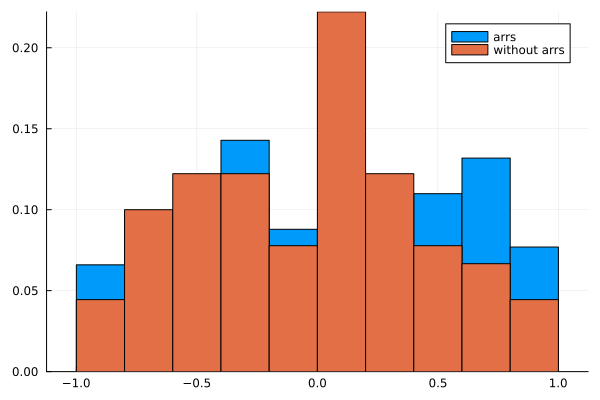

In [37]:
histogram(arr_kendall, normalized=:probability, bins=10, label="arrs")
histogram!(empty_kendall, normalized=:probability, bins=10, label="without arrs")

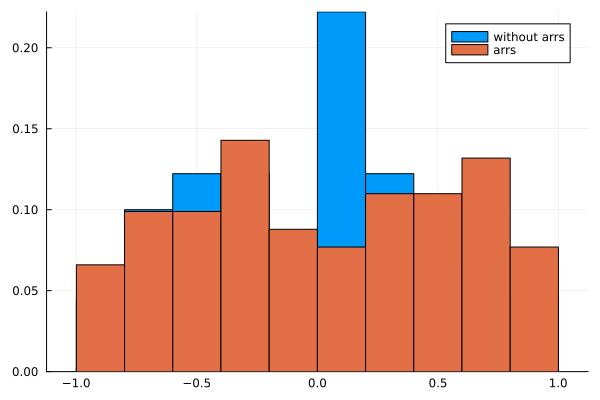

In [38]:
histogram(empty_kendall, normalized=:probability, bins=10, label="without arrs")
histogram!(arr_kendall, normalized=:probability, bins=10, label="arrs")

In [32]:
length(arr_kendall)

91